In [1]:
import pandas as pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df.head()


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day_name()

df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday'])

df[['date_time', 'hour', 'day', 'is_weekend']].head()

,date_time,hour,day,is_weekend
0,2012-10-02 09:00:00,9,Tuesday,False
1,2012-10-02 10:00:00,10,Tuesday,False
2,2012-10-02 11:00:00,11,Tuesday,False
3,2012-10-02 12:00:00,12,Tuesday,False
4,2012-10-02 13:00:00,13,Tuesday,False


In [5]:
def traffic_category(x):
    if x < 2000:
        return 'Low'
    elif x < 4000:
        return 'Medium'
    else:
        return 'High'

df['traffic_level'] = df['traffic_volume'].apply(traffic_category)


In [6]:
df[['traffic_volume', 'traffic_level']].head()

,traffic_volume,traffic_level
0,5545,High
1,4516,High
2,4767,High
3,5026,High
4,4918,High


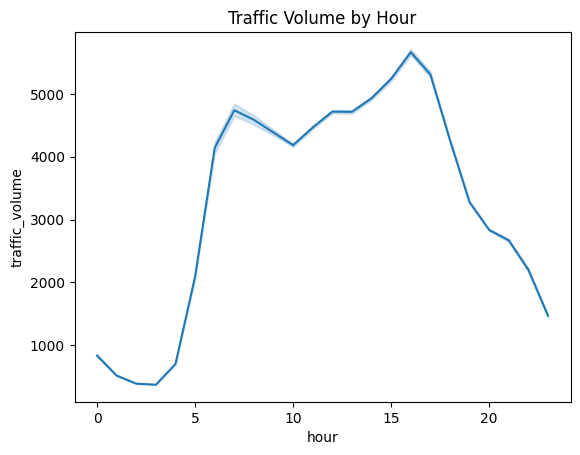

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='hour', y='traffic_volume', data=df)
plt.title("Traffic Volume by Hour")
plt.show()

In [8]:
data = df[['hour', 'weather_main', 'traffic_level']]

In [9]:
data = data.astype(str)

In [11]:
data_encoded = pd.get_dummies(data)

In [15]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(data_encoded, min_support=0.02, use_colnames=True)

frequent_items.head()

,support,itemsets
0,0.042258,(hour_0)
1,0.042507,(hour_1)
2,0.043108,(hour_10)
3,0.040495,(hour_11)
4,0.040557,(hour_12)


In [16]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(hour_0),(traffic_level_Low),0.041905,0.991654,3.140923
1,(hour_1),(traffic_level_Low),0.042507,1.000000,3.167357
2,(hour_10),(traffic_level_High),0.031221,0.724254,1.667317
3,(hour_11),(traffic_level_High),0.033358,0.823770,1.896415
4,(hour_12),(traffic_level_High),0.036429,0.898210,2.067783
5,(hour_13),(traffic_level_High),0.036097,0.913386,2.102720
6,(hour_14),(traffic_level_High),0.037673,0.922296,2.123231
7,(hour_15),(traffic_level_High),0.037300,0.929679,2.140230
8,(hour_16),(traffic_level_High),0.037964,0.920523,2.119151
9,(hour_17),(traffic_level_High),0.035578,0.887222,2.042488


In [18]:
strong_rules = rules[(rules['confidence'] > 0.7) & (rules['lift'] > 1)]

strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(hour_1),(traffic_level_Low),0.042507,0.315721,0.042507,1.000000,3.167357,1.0,0.029087,inf,0.714657,0.134634,1.000000,0.567317
16,(hour_3),(traffic_level_Low),0.042009,0.315721,0.042009,1.000000,3.167357,1.0,0.028746,inf,0.714286,0.133057,1.000000,0.566529
12,(hour_2),(traffic_level_Low),0.041884,0.315721,0.041884,1.000000,3.167357,1.0,0.028661,inf,0.714193,0.132663,1.000000,0.566332
17,(hour_4),(traffic_level_Low),0.043378,0.315721,0.043378,1.000000,3.167357,1.0,0.029683,inf,0.715308,0.137394,1.000000,0.568697
0,(hour_0),(traffic_level_Low),0.042258,0.315721,0.041905,0.991654,3.140923,1.0,0.028564,81.992762,0.711697,0.132581,0.987804,0.562192


In [19]:
def interpret_rules(df):
    for i, row in df.iterrows():
        antecedent = list(row['antecedents'])
        consequent = list(row['consequents'])
        
        print(f"IF {antecedent} THEN {consequent}")
        print(f"Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")
        print("-"*50)

interpret_rules(strong_rules.head(10))

IF ['hour_1'] THEN ['traffic_level_Low']
Confidence: 1.00, Lift: 3.17
--------------------------------------------------
IF ['hour_3'] THEN ['traffic_level_Low']
Confidence: 1.00, Lift: 3.17
--------------------------------------------------
IF ['hour_2'] THEN ['traffic_level_Low']
Confidence: 1.00, Lift: 3.17
--------------------------------------------------
IF ['hour_4'] THEN ['traffic_level_Low']
Confidence: 1.00, Lift: 3.17
--------------------------------------------------
IF ['hour_0'] THEN ['traffic_level_Low']
Confidence: 0.99, Lift: 3.14
--------------------------------------------------
IF ['hour_20'] THEN ['traffic_level_Medium']
Confidence: 0.97, Lift: 3.86
--------------------------------------------------
IF ['hour_19'] THEN ['traffic_level_Medium']
Confidence: 0.95, Lift: 3.81
--------------------------------------------------
IF ['hour_15'] THEN ['traffic_level_High']
Confidence: 0.93, Lift: 2.14
--------------------------------------------------
IF ['hour_14'] THEN ['

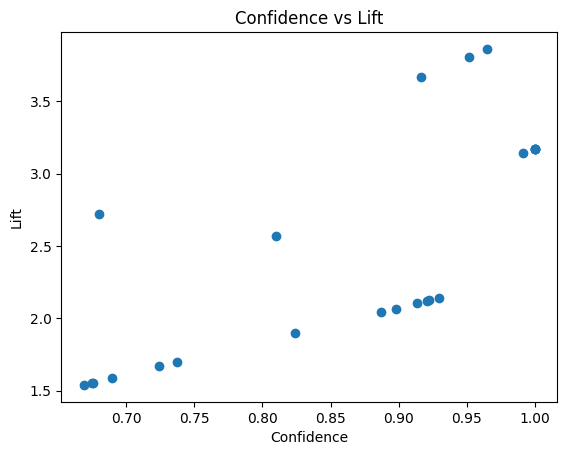

In [20]:
import matplotlib.pyplot as plt

plt.scatter(rules['confidence'], rules['lift'])
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift")
plt.show()

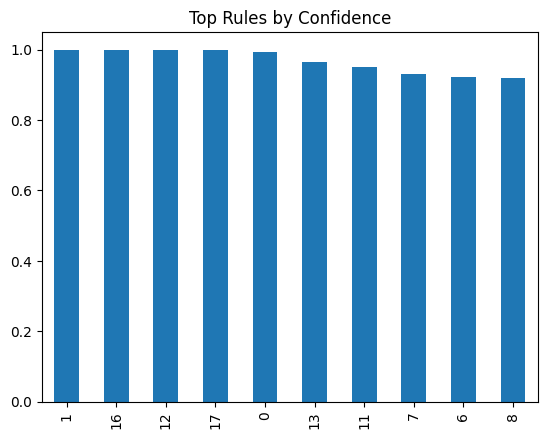

In [21]:
top_rules = rules.sort_values(by='confidence', ascending=False).head(10)

top_rules['confidence'].plot(kind='bar')
plt.title("Top Rules by Confidence")
plt.show()

In [22]:
cluster_data = df[['traffic_volume', 'temp', 'hour']]

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_data)

In [25]:
df[['traffic_volume', 'hour', 'cluster']].head()

,traffic_volume,hour,cluster
0,5545,9,0
1,4516,10,0
2,4767,11,0
3,5026,12,0
4,4918,13,0


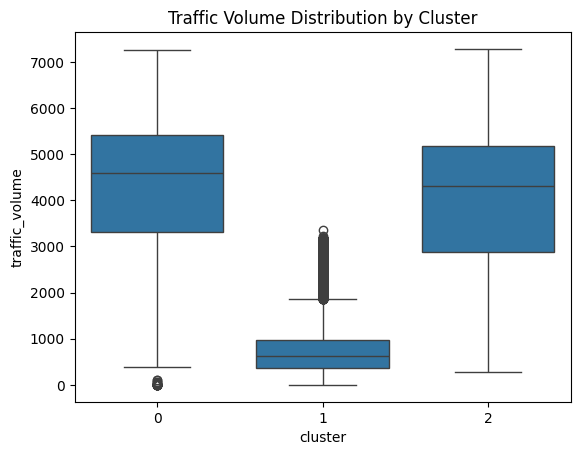

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='cluster', y='traffic_volume', data=df)
plt.title("Traffic Volume Distribution by Cluster")
plt.show()

In [34]:
df.groupby('cluster')[['traffic_volume', 'hour']].mean()

,traffic_volume,hour
cluster,,
0,4372.894183,14.800827
1,882.558094,3.045192
2,4040.062496,14.741997


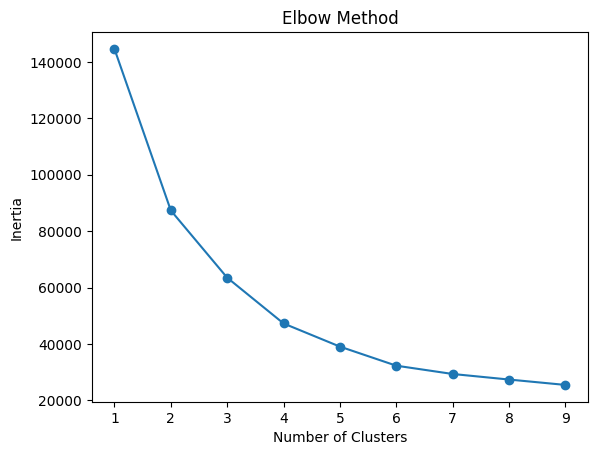

In [28]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

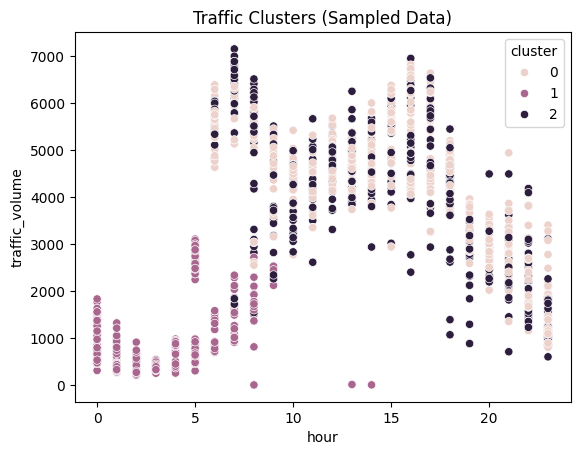

In [36]:
sample_df = df.sample(2000)  # take 2000 points

sns.scatterplot(x='hour', y='traffic_volume', hue='cluster', data=sample_df)
plt.title("Traffic Clusters (Sampled Data)")
plt.show()